In [2]:
from google.colab import files
upload = files.upload()


Saving marketing_AB.csv to marketing_AB.csv


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('marketing_AB.csv')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 588101
Columns: 7


In [4]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
df.columns.tolist()

['Unnamed: 0',
 'user id',
 'test group',
 'converted',
 'total ads',
 'most ads day',
 'most ads hour']

In [6]:
# Remove unnecessary index column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Duplicate rows: 0


In [7]:
df['converted'] = df['converted'].astype(bool)
df['total ads'] = pd.to_numeric(df['total ads'], errors='coerce')

print(df.dtypes)

user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object


In [8]:
print("Dataset shape:", df.shape)

print("\nTest groups:")
print(df['test group'].value_counts())

print("\nConversion results:")
print(df['converted'].value_counts())

Dataset shape: (588101, 6)

Test groups:
test group
ad     564577
psa     23524
Name: count, dtype: int64

Conversion results:
converted
False    573258
True      14843
Name: count, dtype: int64


In [9]:
conversion_rate = df.groupby('test group')['converted'].mean() * 100

print("Conversion Rate (%):")
print(conversion_rate)

Conversion Rate (%):
test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64


In [10]:
conversion_summary = df.groupby('test group')['converted'].agg(
    total_users='count',
    conversions='sum',
    conversion_rate='mean'
).reset_index()

conversion_summary['conversion_rate'] *= 100

conversion_summary

,test group,total_users,conversions,conversion_rate
0,ad,564577,14423,2.554656
1,psa,23524,420,1.785411


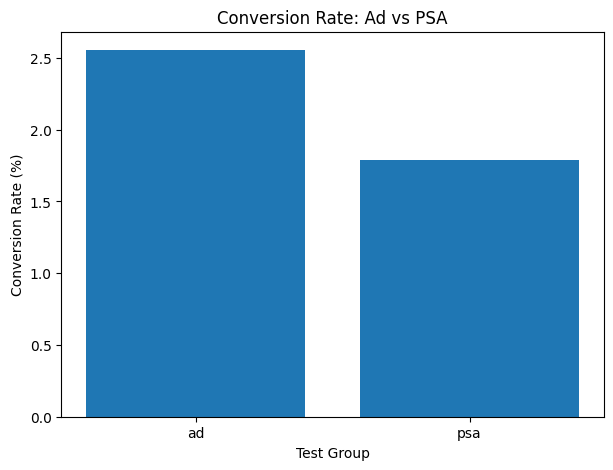

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    conversion_summary['test group'],
    conversion_summary['conversion_rate']
)

plt.title('Conversion Rate: Ad vs PSA')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate (%)')

plt.show()

In [12]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df['test group'],
    df['converted']
)

print(contingency_table)

converted    False  True 
test group               
ad          550154  14423
psa          23104    420


In [13]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 54.005823883685245
p-value: 1.9989623063390075e-13


In [14]:
if p_value < 0.05:
    print("Result: Statistically significant difference in conversion rates.")
else:
    print("Result: No statistically significant difference in conversion rates.")

Result: Statistically significant difference in conversion rates.


In [15]:
from scipy.stats import ttest_ind

ad_group = df[df['test group'] == 'ad']['total ads']
psa_group = df[df['test group'] == 'psa']['total ads']

t_stat, p_value_ttest = ttest_ind(
    ad_group,
    psa_group,
    equal_var=False
)

print("T-statistic:", t_stat)
print("p-value:", p_value_ttest)

T-statistic: 0.21799691449238462
p-value: 0.8274332524963


In [16]:
if p_value_ttest < 0.05:
    print("Result: The average number of ads differs significantly between groups.")
else:
    print("Result: No significant difference in average ads between groups.")

Result: No significant difference in average ads between groups.


In [17]:
from scipy.stats import f_oneway

f_stat, p_value_anova = f_oneway(
    ad_group,
    psa_group
)

print("F-statistic:", f_stat)
print("p-value:", p_value_anova)

F-statistic: 0.04575962620843156
p-value: 0.8306134187285898


In [18]:
if p_value_anova < 0.05:
    print("Result: Significant difference between the groups.")
else:
    print("Result: No significant difference between the groups.")

Result: No significant difference between the groups.


In [19]:
print("===== STATISTICAL TEST SUMMARY =====")

print("\nChi-Square Test")
print("p-value:", p_value)

print("\nIndependent T-Test")
print("p-value:", p_value_ttest)

print("\nOne-Way ANOVA")
print("p-value:", p_value_anova)

print("\nSignificance Level: 0.05")

===== STATISTICAL TEST SUMMARY =====

Chi-Square Test
p-value: 1.9989623063390075e-13

Independent T-Test
p-value: 0.8274332524963

One-Way ANOVA
p-value: 0.8306134187285898

Significance Level: 0.05


In [20]:
conversion_summary = df.groupby('test group')['converted'].agg(
    total_users='count',
    conversions='sum',
    conversion_rate='mean'
).reset_index()

conversion_summary['conversion_rate'] *= 100

conversion_summary

,test group,total_users,conversions,conversion_rate
0,ad,564577,14423,2.554656
1,psa,23524,420,1.785411


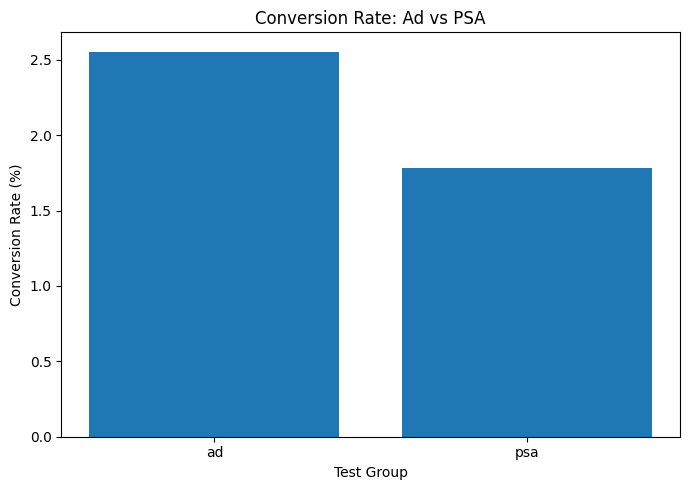

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    conversion_summary['test group'],
    conversion_summary['conversion_rate']
)

plt.title('Conversion Rate: Ad vs PSA')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()